<a href="https://colab.research.google.com/github/scalabrinig/cdProjetoAplicadoIV/blob/master/projeto/cd_projeto_aplicado_IV_entrega_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/01**


# **Entrega 3**

---

# **Título do Projeto**: **INCIDÊNCIA DE DENGUE NO ESTADO DE SÃO PAULO**

---


In [1]:
#@title **Identificação do Grupo e Opção do Projeto**

#@markdown Integrantes do grupo, nome completo e matrícula, em ordem alfabética (formato: nome, matrícula)
Aluno1 = 'Brenno Monteiro, 10435051' #@param {type:"string"}
Aluno2 = 'Bruno Mascarini, 10433508' #@param {type:"string"}
Aluno3 = 'Lucas Camargo, 10442957' #@param {type:"string"}
Aluno4 = 'Marina Camargo, 10441143' #@param {type:"string"}
Aluno5 = 'None' #@param {type:"string"}


# **Introdução**

A dengue permanece central no cuidado em saúde pública e o estado de São Paulo oferece série temporal com granularidade semanal, condição adequada para explorar a variabilidade e testar um primeiro modelo (OPAS, s.d.) (WHO, 2025). Esta entrega 3 aprofunda a etapa de exploração de dados, preparação e estimação de modelos iniciais de referência coerentes com o desenho do projeto.

A motivação consiste em produzir evidência reproduzível sobre a série estadual, documentar a qualidade dos dados e as limitações encontradas, e apresentar um primeiro modelo a refinar na entrega final, de acordo com a literatura de vigilância e com boas práticas de validação temporal (FIOCRUZ, s.d.). O objetivo geral é apoiar a leitura da dinâmica de casos e a previsão de curto prazo. Os objetivos específicos desta entrega são: (1) realizar a análise exploratória e o pré-processamento da base estadual, (2) definir a tarefa de previsão com valores de semanas anteriores e recorte temporal acordado, (3) treinar modelos de referência com partição cronológica, (4) relatar o desempenho com MAE, RMSE e, quando apropriado, MAPE.

A base de dados processada de forma completa no código é o arquivo `infodengue_dengue_sp_state.csv` (agregado estadual) na pasta do repositório. A implementação fica limitada ao arquivo estadual. A base municipal entra no escopo do trabalho, mas **não** é carregada neste *notebook*. O objetivo é alinhar o recorte à documentação de junção de fontes, como descrito na seção de EDA. A delimitação se apoia em clareza metodológica, reprodutibilidade e no uso de um primeiro modelo como referência antes de abordagens mais complexas, de acordo com recomendações de transparência em saúde (BRASIL, s.d.) (WHO, 2025).


# **Referencial Teórico**

A análise exploratória em séries epidemiológicas reúne a descrição da variável a prever, o estudo do padrão sazonal e a checagem de problemas de qualidade. Em dados de notificação, atrasos e reabertura de registros explicam parte da variação observada, fatores a considerar na interpretação dos resultados (FIOCRUZ, s.d.) (OPAS, s.d.).

A previsão de curto prazo, com horizonte de uma semana, costuma utilizar valores anteriores da própria série e outras variáveis explicativas disponíveis, mantendo a ordem temporal na validação (PEDREGOSA et al., 2011). A regressão linear com penalização, como o método Ridge, oferece resultados de fácil interpretação e limita os coeficientes quando as variáveis preditoras são parecidas entre si (PEDREGOSA et al., 2011).

A literatura de vigilância recomenda métricas como MAE e RMSE para medir o erro de previsão, sendo que o RMSE penaliza mais os erros maiores. O MAPE requer cuidado quando os valores observados são muito pequenos ou próximos de zero (WHO, 2025). Abordagens mais complexas podem reduzir o erro em séries longas, mas exigem mais dados, maior esforço de ajuste e cuidado com sobreajuste. O modelo de referência linear serve como ponto de partida para refinamentos futuros, com custo computacional baixo e resultado de fácil interpretação (PEDREGOSA et al., 2011). A escolha metodológica privilegia clareza e coerência com o fluxo definido no projeto, deixando para etapas futuras as comparações mais amplas entre diferentes abordagens.

Trabalhos anteriores aplicaram diferentes técnicas para prever dengue em São Paulo e no Brasil. Baquero, Santana e Chiaravalloti-Neto (2018) compararam modelos autorregressivos sazonais (SARIMA), modelos aditivos generalizados (GAM) e redes neurais artificiais para a cidade de São Paulo, concluindo que o GAM com defasagens de casos e variáveis meteorológicas apresentou o melhor desempenho e que modelos mais complexos só se justificam quando superam benchmarks mais simples. Sebastianelli et al. (2024) propuseram um conjunto de modelos de aprendizado de máquina (CatBoost, SVM e LSTM combinados com floresta aleatória) para previsão estadual no Brasil, demonstrando a aplicabilidade de abordagens de conjunto em contextos com dados de saúde pública. Em comparação, modelos estatísticos clássicos tendem a ser mais simples de implementar e mais fáceis de interpretar, enquanto métodos como a floresta aleatória, introduzida por Breiman (2001), oferecem maior flexibilidade para capturar relações não lineares ao custo de menor transparência e maior esforço de ajuste. Nesta entrega, os dois modelos foram avaliados nas mesmas condições para verificar qual apresenta menor erro de previsão na série estadual de São Paulo.


# **Diagrama de Solução**

O diagrama abaixo representa o fluxo de trabalho adotado nesta entrega. Cada etapa alimenta a seguinte: a qualidade da aquisição e da análise exploratória determina a consistência das variáveis construídas e, consequentemente, a confiabilidade do modelo.

```mermaid
flowchart TB
  A["Aquisição dos Dados<br/>Leitura da série semanal estadual do InfoDengue/SP<br/>Verificação de nulos, duplicatas e recorte temporal a partir de 2015"]

  B["Análise Exploratória<br/>Evolução temporal dos casos estimados<br/>Padrão sazonal mensal e relação exploratória com temperatura e umidade"]

  C["Preparação das Variáveis<br/>Criação de indicador mensal e variáveis de memória da série<br/>Definição da variável-alvo para previsão de curto prazo"]

  D["Treinamento e Validação<br/>Regressão Ridge e Floresta aleatória sobre variáveis sazonais e de memória<br/>Partição cronológica 80/20 com avaliação e comparação de desempenho"]

  E["Análise dos Resultados<br/>Comparação entre valores observados e previstos no período de teste<br/>Discussão das limitações dos modelos e encaminhamentos para a entrega final"]

  A --> B --> C --> D --> E

  style A fill:#1a6fad,color:#fff,stroke:#0d4d7a
  style B fill:#1a6fad,color:#fff,stroke:#0d4d7a
  style C fill:#1a6fad,color:#fff,stroke:#0d4d7a
  style D fill:#2e7d32,color:#fff,stroke:#1b5e20
  style E fill:#6a1b9a,color:#fff,stroke:#4a148c
```


# **Inicialização do ambiente**

A célula a seguir carrega as bibliotecas necessárias para análise, visualização e modelagem, além da base de dados com recorte temporal a partir de 2015-01-01.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

csv_path = "C:\caminho_do_dataset"

df = pd.read_csv(csv_path)
df['week_start_date'] = pd.to_datetime(df['week_start_date'])
df = df.sort_values('week_start_date').reset_index(drop=True)
df = df[df['week_start_date'] >= '2015-01-01'].copy()

print('Quantidade de semanas (linhas) no recorte: ', len(df))
print('Intervalo de datas coberto: de ', df['week_start_date'].min().date(), ' a ', df['week_start_date'].max().date(), sep='')

Quantidade de semanas (linhas) no recorte:  581
Intervalo de datas coberto: de 2015-01-04 a 2026-02-15


# **EDA e Pré-processamento dos dados**

Os dados utilizados nesta etapa referem-se ao agregado estadual de São Paulo, disponibilizados pelo InfoDengue (FIOCRUZ, s.d.). Esta entrega analisa exclusivamente a série estadual. A integração com a base municipal está prevista para uma etapa posterior do projeto.

A análise exploratória examina a qualidade dos dados, a evolução temporal da incidência e o padrão sazonal. O pré-processamento cria as variáveis necessárias ao modelo: um indicador do mês do calendário, registros anteriores dos casos para representar o comportamento recente da série, e a variável que o modelo deverá prever. Cada etapa é acompanhada de interpretação no contexto da incidência de dengue no estado de São Paulo.

Abaixo descreve-se a **estrutura** do conjunto (granularidade, variáveis e significado) e, em seguida, executam-se os passos de verificação e análise, em linha com o fluxo proposto no projeto.


### Estrutura do conjunto e significado das variáveis

O arquivo `infodengue_dengue_sp_state.csv` contém **uma linha para cada semana** e o **estado de São Paulo** como unidade (série agregada, sem município). Após o carregamento, o `pandas` atribui tipos a cada coluna: contagens e identificadores em números inteiros, estimativas e medidas climáticas em números de ponto flutuante, e a data em tipo data. A **quantidade de linhas** e o **intervalo de datas** exatos vêm indicados na célula de inicialização (já que dependem do arquivo entregue).

Os **nomes das colunas** abaixo são os que vêm do arquivo. No código, reutilizam-se tais identificadores. O que importa é o **significado** de cada variável, descrito de forma completa, sem abreviaturas que exijam conhecimento prévio além do contexto de vigilância em saúde.

| Campo no arquivo | O que a variável representa |
|------------------|----------------------------|
| `epi_week` | Identificador numérico da **semana epidemiológica**, segundo o calendário adotado pelo InfoDengue. |
| `week_start_date` | **Data de início** da semana a que a linha se refere (cada registro agrega a semana que começa nessa data). |
| `notified_cases` | Número de **casos notificados** à rede de vigilância epidemiológica naquela semana. |
| `estimated_cases` | Número de **casos estimados** (modelo de correção do InfoDengue, distinto da notificação bruta). É a principal série usada na análise e na previsão. |
| `probable_cases` | Número de **casos prováveis** conforme as regras de classificação do sistema. |
| `lab_confirmed_cases` | Número de **casos confirmados por exame de laboratório** na semana. |
| `population` | **População** usada como base para a taxa. Serve de denominador quando se calcula incidência. |
| `temperature_avg` | **Temperatura média** do ar na semana, em graus Celsius, agregada para o recorte. |
| `temperature_max` | **Média das temperaturas máximas** diárias ao longo da semana, em graus Celsius. |
| `temperature_min` | **Média das temperaturas mínimas** diárias ao longo da semana, em graus Celsius. |
| `humidity_avg` | **Umidade relativa média** do ar na semana, em percentual. |
| `humidity_max` | **Média das umidades máximas** registro a registro na semana, em percentual. |
| `humidity_min` | **Média das umidades mínimas** registro a registro na semana, em percentual. |
| `incidence_100k` | **Incidência por 100.000 habitantes** na semana, permitindo comparar o risco ajustado ao tamanho da população. |

A documentação de referência do InfoDengue detalha o método de **estimativa** de casos e a construção das variáveis. Aqui, o foco é garantir leitura correta das colunas ao reproduzir a análise (FIOCRUZ, s.d.).


**Passo 1: Integridade e tratamento de ausentes.** A verificação de valores faltantes e de registros duplicados permite avaliar a consistência da série semanal. Nas variáveis climáticas, valores ausentes são preenchidos por interpolação linear, preservando a continuidade temporal da série. Para os demais campos epidemiológicos, a ausência de valores indica inconsistência que requer documentação antes do uso.

A célula seguinte mostra, em ordem: (1) a distribuição de faltantes por coluna, quando houver (se a primeira tabela não for exibida, não há faltantes), (2) a chave usada na checagem de duplicata e a respectiva contagem, e (3) se existir coluna de clima, quantas células estavam ausentes antes e depois da interpolação. Se não houver colunas de clima na base, essa etapa de interpolação simplesmente não se aplica.


In [3]:
na_counts = df.isna().sum()
key = 'epi_week' if 'epi_week' in df.columns else 'week_start_date'
dups = df.duplicated(subset=[key]).sum()

if (na_counts > 0).any():
    print(
        na_counts[na_counts > 0]
        .rename('faltantes_por_coluna')
        .to_frame()
        .to_string()
    )
    print()
print(pd.DataFrame([{'chave_unicidade': key, 'duplicatas': int(dups)}]).to_string(index=False))
print()

climate_cols = [c for c in ['temperature_avg', 'humidity_avg', 'temperature_min',
                            'temperature_max', 'humidity_min', 'humidity_max'] if c in df.columns]
if climate_cols:
    before = df[climate_cols].isna().sum().sum()
    df[climate_cols] = df[climate_cols].interpolate(method='linear', limit_direction='both')
    after = df[climate_cols].isna().sum().sum()
    print(
        pd.DataFrame(
            [{'clima_celulas_ausentes_antes': before, 'clima_celulas_ausentes_depois': after}]
        ).to_string(index=False)
    )


                 faltantes_por_coluna
temperature_avg                    11
temperature_max                    11
humidity_avg                       11
humidity_min                       11

chave_unicidade  duplicatas
       epi_week           0

 clima_celulas_ausentes_antes  clima_celulas_ausentes_depois
                           44                              0


**Passo 2: Série temporal e tendência.** O gráfico apresenta a evolução semanal dos casos estimados no estado de São Paulo. Os picos e as quedas refletem tanto a sazonalidade da doença quanto eventos específicos de transmissão. A média móvel de 52 semanas suaviza as oscilações semanais e destaca mudanças mais lentas ao longo dos anos, ajudando a separar o que é variação sazonal esperada do que pode indicar uma alteração no padrão da doença, conforme documentado pela literatura de vigilância epidemiológica (FIOCRUZ, s.d.).


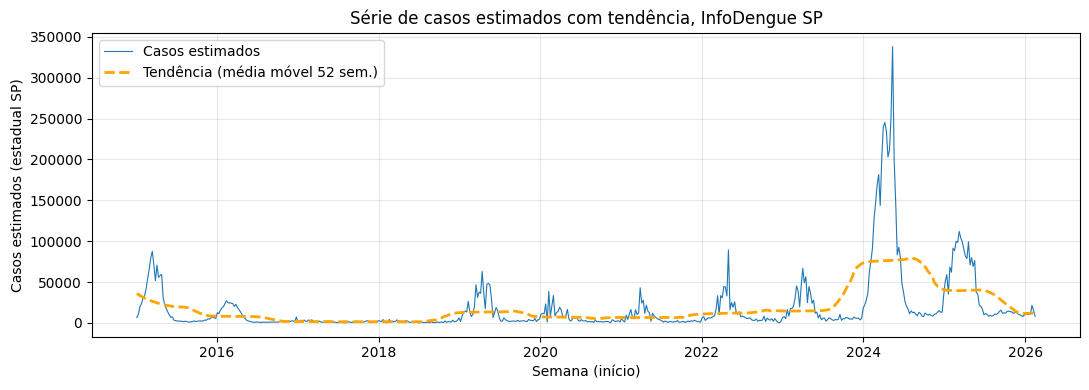

In [4]:
rolling = df['estimated_cases'].rolling(window=52, center=True, min_periods=26).mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df['week_start_date'], df['estimated_cases'], color='C0', linewidth=0.8, label='Casos estimados')
ax.plot(df['week_start_date'], rolling, color='orange', linewidth=2, linestyle='--', label='Tendência (média móvel 52 sem.)')
ax.set_xlabel('Semana (início)')
ax.set_ylabel('Casos estimados (estadual SP)')
ax.set_title('Série de casos estimados com tendência, InfoDengue SP')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Passo 3: Sazonalidade.** A média de casos por mês de calendário evidencia o padrão sazonal da dengue em São Paulo, com concentração nos meses de verão. Essa variação justifica a inclusão do mês como variável preditora no modelo.


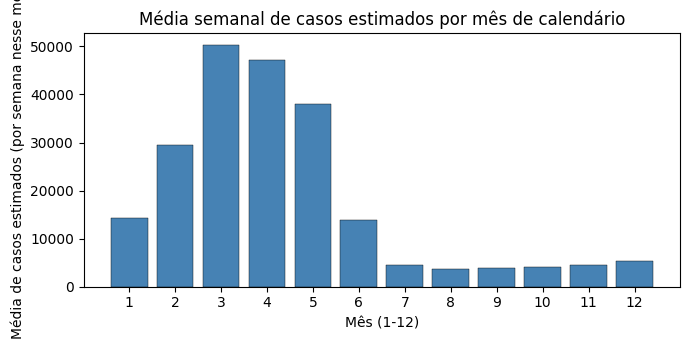

In [5]:
_t = df.copy()
_t['month'] = _t['week_start_date'].dt.month
monthly = _t.groupby('month', as_index=True)['estimated_cases'].mean()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(monthly.index.astype(int), monthly.values, color='steelblue', edgecolor='black', linewidth=0.3)
ax.set_xlabel('Mês (1-12)')
ax.set_ylabel('Média de casos estimados (por semana nesse mês)')
ax.set_title('Média semanal de casos estimados por mês de calendário')
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()


**Passo 4: Variáveis climáticas.** Quando disponíveis, temperatura e umidade são analisadas em relação ao volume de casos. A incorporação dessas variáveis no modelo fica condicionada à disponibilidade e à qualidade dos dados na série. O gráfico de dispersão só é exibido quando as colunas necessárias existem e trazem ao menos um valor numérico. Se o gráfico não aparecer, os dados de clima estão indisponíveis ou vazios, conforme o critério descrito neste parágrafo, sem mensagem adicional no código.


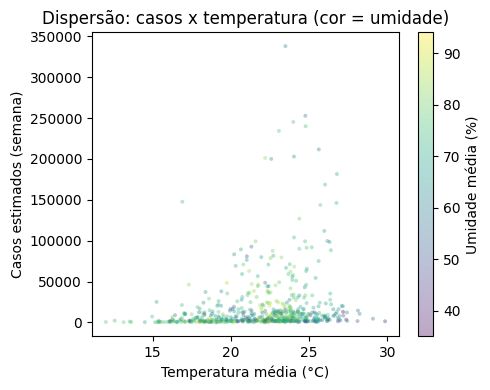

In [6]:
if 'temperature_avg' in df.columns and 'humidity_avg' in df.columns:
    if df[['temperature_avg', 'humidity_avg']].notna().any().any():
        fig, ax = plt.subplots(figsize=(5, 4))
        s = ax.scatter(
            df['temperature_avg'], df['estimated_cases'], c=df['humidity_avg'],
            cmap='viridis', alpha=0.35, s=8, edgecolor='none',
        )
        plt.colorbar(s, label='Umidade média (%)', ax=ax)
        ax.set_xlabel('Temperatura média (°C)')
        ax.set_ylabel('Casos estimados (semana)')
        ax.set_title('Dispersão: casos x temperatura (cor = umidade)')
        plt.tight_layout()
        plt.show()


**Passo 5: Construção das variáveis.** São criadas as variáveis que o modelo usará para fazer as previsões: o número do mês do calendário, para representar a sazonalidade, os casos estimados das quatro semanas anteriores, para levar em conta o que aconteceu recentemente na série, e os casos da semana seguinte, que é o valor a prever. As primeiras linhas da série perdem esses registros anteriores e são excluídas do conjunto de ajuste. O número exibido pela célula abaixo é o total de linhas no conjunto antes dessa exclusão.

In [7]:
df['month'] = df['week_start_date'].dt.month
for k in range(1, 5):
    df[f'lag{k}'] = df['estimated_cases'].shift(k)
df['y'] = df['estimated_cases'].shift(-1)
len(df)


581

**Passo 6: Semanas de pico.** As semanas com maior incidência são identificadas como aquelas em que os casos estimados superam dois desvios padrão acima da média histórica. Esse critério vai além da variação sazonal esperada e aponta períodos em que a transmissão foi atipicamente elevada, o que pode indicar epidemias mais intensas dentro do calendário anual. A célula seguinte mostra o valor de referência calculado, quantas semanas o ultrapassam e as dez com maior registro, em ordem decrescente.


In [8]:
threshold = df['estimated_cases'].mean() + 2 * df['estimated_cases'].std()
peaks = df[df['estimated_cases'] > threshold][['week_start_date', 'estimated_cases']].copy()
peaks = peaks.sort_values('estimated_cases', ascending=False).reset_index(drop=True)

print(
    pd.DataFrame(
        [{
            'limiar_casos_estimados': round(threshold, 1),
            'semanas_acima_do_limiar': len(peaks),
        }]
    ).to_string(index=False)
)
print()
print(peaks.head(10).to_string(index=False))


 limiar_casos_estimados  semanas_acima_do_limiar
                92632.6                       22

week_start_date  estimated_cases
     2024-05-12         338073.0
     2024-05-05         252873.0
     2024-04-07         245316.0
     2024-03-31         240116.0
     2024-04-14         234367.0
     2024-04-28         211733.0
     2024-04-21         203003.0
     2024-03-24         201260.0
     2024-05-19         200126.0
     2024-03-10         181586.0


# **Modelo base**

Nesta etapa são aplicadas duas técnicas para prever os casos estimados da semana seguinte. As duas foram ajustadas com as mesmas variáveis e avaliadas no mesmo período de teste, o que permite comparar os resultados em condições equivalentes. A avaliação segue partição cronológica: os dados mais antigos são usados para treino e os mais recentes para teste, evitando que o modelo acesse informações do futuro durante o aprendizado (PEDREGOSA et al., 2011).

**Técnica 1: Regressão Ridge.** Modelo de regressão linear que inclui uma penalização sobre os coeficientes, impedindo que alguma variável receba peso excessivo. Isso é especialmente útil quando os valores de semanas anteriores são parecidos entre si e poderiam distorcer as estimativas. O resultado é um modelo simples, de fácil interpretação e adequado como referência linear.

**Técnica 2: Floresta aleatória.** Conjunto de árvores de decisão treinadas sobre diferentes subconjuntos dos dados de treino. A previsão final combina o resultado de todas as árvores pela média. O método é capaz de capturar relações mais complexas entre as variáveis sem que seja necessário definir de antemão como elas se relacionam. A comparação com a regressão Ridge permite verificar o ganho ao usar uma abordagem com maior flexibilidade.


**Passo 1: Partição temporal.** Os dados são divididos em ordem cronológica: os 80% iniciais compõem o conjunto de treino e os 20% finais, o conjunto de teste. Essa abordagem preserva a sequência das observações epidemiológicas e impede que o modelo acesse informações do futuro durante o treinamento. A célula seguinte mostra, em tabela, intervalo de datas e quantidade de semanas de treino e de teste.


In [9]:
use_climate = 'temperature_avg' in df.columns and 'humidity_avg' in df.columns
feat = ['month', 'lag1', 'lag2', 'lag3', 'lag4']
if use_climate:
    feat = feat + ['temperature_avg', 'humidity_avg']
data = df.dropna(subset=['y'] + feat).copy()
n = len(data)
split = max(1, int(np.floor(0.8 * n)))
train, test = data.iloc[:split].copy(), data.iloc[split:].copy()
X_train, y_train = train[feat], train['y']
X_test, y_test = test[feat], test['y']
print(
    pd.DataFrame(
        {
            'conjunto': ['treino', 'teste'],
            'data_inicio': [
                train['week_start_date'].min().date(),
                test['week_start_date'].min().date(),
            ],
            'data_fim': [
                train['week_start_date'].max().date(),
                test['week_start_date'].max().date(),
            ],
            'quantidade_semanas': [len(train), len(test)],
        }
    ).to_string(index=False)
)


conjunto data_inicio   data_fim  quantidade_semanas
  treino  2015-02-01 2023-11-19                 460
   teste  2023-11-26 2026-02-08                 116


**Passo 2: Ajuste e métricas (Regressão Ridge).** O modelo é ajustado com os dados de treino e avaliado nos dados de teste. O desempenho é medido por três métricas: o erro absoluto médio (MAE), que indica quantos casos o modelo erra por semana em média; a raiz do erro quadrático médio (RMSE), que penaliza mais os erros maiores; e o erro percentual absoluto médio (MAPE), que expressa o desvio em termos relativos. O MAPE é omitido quando uma parte relevante dos valores observados está muito próxima de zero, pois nesse caso a métrica perde sentido. Quando isso ocorre, apenas MAE e RMSE são reportados.


In [10]:
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
eps = 1e-6
if (np.abs(y_test.values) > eps).mean() > 0.9:
    mape = np.mean(np.abs((y_test - y_pred) / np.maximum(np.abs(y_test), eps))) * 100
else:
    mape = None
linha = {
    'erro_absoluto_medio_casos': round(mae, 1),
    'raiz_erro_quadratico_medio_casos': round(rmse, 1),
    'erro_percentual_absoluto_medio': round(mape, 2) if mape is not None else None,
}
print(pd.DataFrame([linha]).T.rename(columns={0: 'teste'}).to_string())


                                     teste
erro_absoluto_medio_casos         17491.20
raiz_erro_quadratico_medio_casos  32885.70
erro_percentual_absoluto_medio       32.62


**Passo 3: Observado e previsto (Regressão Ridge).** O gráfico compara os casos estimados observados com as previsões do modelo no período de teste. Quanto mais próximas as duas curvas, melhor o modelo acompanha o comportamento real da incidência ao longo do período.


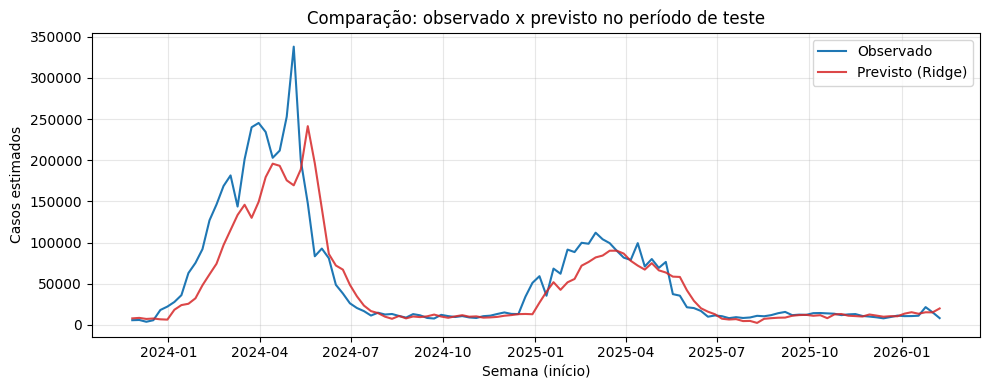

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test['week_start_date'], y_test.values, label='Observado', color='C0')
ax.plot(test['week_start_date'], y_pred, label='Previsto (Ridge)', color='C3', alpha=0.85)
ax.set_xlabel('Semana (início)')
ax.set_ylabel('Casos estimados')
ax.legend()
ax.set_title('Comparação: observado x previsto no período de teste')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Passo 4: Inspeção de resíduos (Regressão Ridge).** O gráfico mostra a diferença entre o valor observado e o previsto ao longo do tempo. Se os erros aparecerem concentrados em determinados períodos ou seguirem uma tendência visível, isso indica que o modelo não está captando algum comportamento da série. Abaixo do gráfico, a tabela resume a média e o desvio padrão dos erros no conjunto de teste.


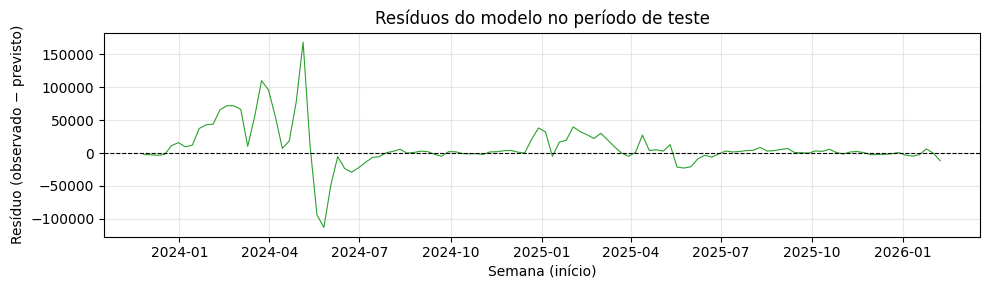

 media_residuos_casos  desvio_padrao_residuos_casos
               8718.5                       31709.0


In [12]:
residuals = y_test.values - y_pred

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(test['week_start_date'], residuals, color='C2', linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Semana (início)')
ax.set_ylabel('Resíduo (observado − previsto)')
ax.set_title('Resíduos do modelo no período de teste')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(
    pd.DataFrame(
        [{
            'media_residuos_casos': round(residuals.mean(), 1),
            'desvio_padrao_residuos_casos': round(residuals.std(), 1),
        }]
    ).to_string(index=False)
)


**Passo 5: Floresta aleatória, ajuste e métricas.** O modelo é treinado sobre o mesmo conjunto de treino e avaliado no mesmo conjunto de teste utilizado pela regressão Ridge, de modo que os resultados sejam diretamente comparáveis. As mesmas métricas (MAE, RMSE e MAPE) são calculadas. O erro absoluto médio indica quantos casos o modelo erra, em média, por semana. A raiz do erro quadrático médio penaliza erros maiores, sendo mais sensível a semanas em que a previsão desvia bastante do valor real. O erro percentual absoluto médio expressa o desvio em termos relativos ao volume observado.

In [13]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = float(np.sqrt(mean_squared_error(y_test, y_pred_rf)))
eps = 1e-6
if (np.abs(y_test.values) > eps).mean() > 0.9:
    mape_rf = np.mean(np.abs((y_test - y_pred_rf) / np.maximum(np.abs(y_test), eps))) * 100
else:
    mape_rf = None
linha_rf = {
    'erro_absoluto_medio_casos': round(mae_rf, 1),
    'raiz_erro_quadratico_medio_casos': round(rmse_rf, 1),
    'erro_percentual_absoluto_medio': round(mape_rf, 2) if mape_rf is not None else None,
}
print(pd.DataFrame([linha_rf]).T.rename(columns={0: 'teste'}).to_string())

                                     teste
erro_absoluto_medio_casos         28456.70
raiz_erro_quadratico_medio_casos  56727.00
erro_percentual_absoluto_medio       41.18


**Passo 6: Observado e previsto (Floresta aleatória).** O gráfico compara os casos estimados observados com as previsões da floresta aleatória no período de teste, no mesmo formato utilizado para a regressão Ridge.

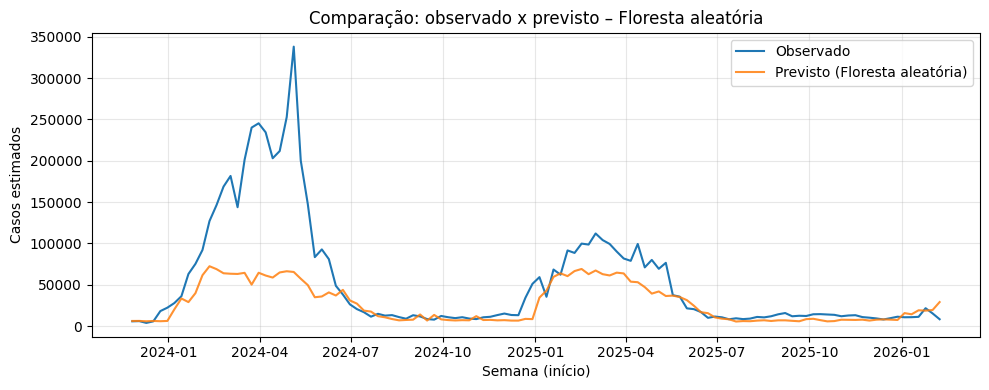

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test['week_start_date'], y_test.values, label='Observado', color='C0')
ax.plot(test['week_start_date'], y_pred_rf, label='Previsto (Floresta aleatória)', color='C1', alpha=0.85)
ax.set_xlabel('Semana (início)')
ax.set_ylabel('Casos estimados')
ax.legend()
ax.set_title('Comparação: observado x previsto – Floresta aleatória')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Passo 7: Comparação dos modelos.** A tabela reúne as métricas de ambos os modelos no mesmo conjunto de teste. Em todas as três métricas, valores menores indicam melhor desempenho. A comparação permite identificar qual técnica erra menos ao prever os casos da semana seguinte e serve de base para decidir qual abordagem será aprofundada na entrega final.

In [15]:
comparacao = pd.DataFrame(
    {
        'modelo': ['Ridge', 'Floresta aleatória'],
        'erro_absoluto_medio_casos': [round(mae, 1), round(mae_rf, 1)],
        'raiz_erro_quadratico_medio_casos': [round(rmse, 1), round(rmse_rf, 1)],
        'erro_percentual_absoluto_medio': [
            round(mape, 2) if mape is not None else None,
            round(mape_rf, 2) if mape_rf is not None else None,
        ],
    }
)
print(comparacao.to_string(index=False))

            modelo  erro_absoluto_medio_casos  raiz_erro_quadratico_medio_casos  erro_percentual_absoluto_medio
             Ridge                    17491.2                           32885.7                           32.62
Floresta aleatória                    28456.7                           56727.0                           41.18


# **Limitações e encaminhamentos**

O modelo de referência apresentado nesta entrega estabelece um ponto de partida mensurável, mas carrega limitações que devem ser consideradas na interpretação dos resultados e no planejamento das próximas etapas.

**(1) Limitações principais.** (a) Os modelos avaliados operam com variáveis fixas de memória da série e sazonalidade mensal, o que limita a capacidade de capturar mudanças abruptas na dinâmica de transmissão. (b) O horizonte de previsão de uma semana reduz a utilidade prática para o planejamento de médio prazo. (c) A base municipal não foi integrada nesta entrega, o que impede comparações entre regiões do estado e pode ocultar diferenças importantes de comportamento entre municípios. (d) As variáveis climáticas com valores ausentes foram preenchidas por interpolação linear, o que introduz algum grau de incerteza nos períodos com maior quantidade de lacunas.

**(2) Encaminhamentos para a entrega final.** Os próximos passos incluem: (a) avaliar modelos com maior capacidade de capturar padrões não lineares na série, (b) incorporar a base municipal para análise comparativa entre regiões, (c) ampliar as variáveis preditoras com indicadores climáticos e epidemiológicos adicionais, e (d) adotar validação por janela deslizante para uma estimativa mais próxima do desempenho esperado na prática.


# **Cronograma**

![Cronograma](cronograma.png)

Cronograma visual da disciplina com os marcos de entrega.


# **Referências**

FUNDAÇÃO OSWALDO CRUZ (FIOCRUZ). InfoDengue: Sistema de Alerta para Arboviroses. Disponível em: https://info.dengue.mat.br/. Acesso em: 1 mar. 2026.

MINISTÉRIO DA SAÚDE (BRASIL). Dengue: causas, sintomas, prevenção e tratamento. Disponível em: https://www.gov.br/saude/pt-br/assuntos/saude-de-a-a-z/d/dengue. Acesso em: 1 mar. 2026.

ORGANIZAÇÃO PAN-AMERICANA DA SAÚDE (OPAS). Dengue. Disponível em: https://www.paho.org/pt/topicos/dengue. Acesso em: 1 mar. 2026.

BAQUERO, O. S.; SANTANA, L. M. R.; CHIARAVALLOTI-NETO, F. Dengue forecasting in São Paulo city with generalized additive models, artificial neural networks and seasonal autoregressive integrated moving average models. *PLoS ONE*, v. 13, n. 4, e0195065, 2018. Disponível em: https://doi.org/10.1371/journal.pone.0195065. Acesso em: 25 abr. 2026.

BREIMAN, L. Random forests. *Machine Learning*, v. 45, n. 1, p. 5-32, 2001. Disponível em: https://doi.org/10.1023/A:1010933404324. Acesso em: 25 abr. 2026.

PEDREGOSA, F. et al. Scikit-learn: machine learning in Python. *Journal of Machine Learning Research*, v. 12, p. 2825-2830, 2011. Disponível em: https://jmlr.org/papers/v12/pedregosa11a.html. Acesso em: 25 abr. 2026.

SEBASTIANELLI, A.; SPILLER, D.; CARMO, R. et al. A reproducible ensemble machine learning approach to forecast dengue outbreaks. *Scientific Reports*, v. 14, p. 3807, 2024. Disponível em: https://doi.org/10.1038/s41598-024-52796-9. Acesso em: 25 abr. 2026.

WORLD HEALTH ORGANIZATION (WHO). Dengue and severe dengue. Disponível em: https://www.who.int/news-room/fact-sheets/detail/dengue-and-severe-dengue. Acesso em: 1 mar. 2026.


In [16]:
#@title **Avaliação**
EDA_e_preprocessamento = 10 #@param {type:"slider", min:0, max:10, step:1}

Modelo_base = 10 #@param {type:"slider", min:0, max:10, step:1}

In [17]:
#@title **Nota Final**
nota = 0.50*EDA_e_preprocessamento + 0.50*Modelo_base

print(f'Nota final do trabalho {nota :.1f}')

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
print(alunos.to_string(index=False))

Nota final do trabalho 10.0

           nome  nota
Brenno Monteiro  10.0
Bruno Mascarini  10.0
  Lucas Camargo  10.0
 Marina Camargo  10.0
